# TOPP-HATT

Given some tree, restrict the node and leaf choices of HATT to find the minimum pauli-weight and weighted-pauli-weight tree.

In [1]:
# Import coefficients
import pickle
from ferrmion.encode import TernaryTree
from pathlib import Path

def water_integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
        ones = pickle.load(file)

    with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
        twos = pickle.load(file)
    return (ones, twos)
ones, twos = water_integrals()
twos *= 0.5

In [2]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.encode import TernaryTree
from ferrmion.encode.ternary_tree_node import TTNode
from ferrmion.visualise import draw_tt, symplectic_matshow
# from openfermion.chem.pubchem import geometry_from_pubchem
# from openfermion.chem.molecular_data import MolecularData
# from openfermion.chem.molecular_data import spinorb_from_spatial
# import openfermionpyscf
# import openfermion
# geometry=geometry_from_pubchem("H2O")
# mol = MolecularData(geometry=geometry, basis="sto-3g", multiplicity=1)
# mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
# ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)

In [3]:
"""Code to Geneate Hamiltonian Adaptive Ternary Tree from Majorana Hamiltonian."""

from itertools import permutations
from typing import Iterable

import numpy as np

from ferrmion.encode import TernaryTree
from ferrmion.encode.ternary_tree_node import TTNode

def _reduce_hamiltonian(
    majorana_ham: dict[Iterable[int], float],
    parent_index: int,
    selection: tuple[int, int, int],
) -> dict[tuple[int, ...], float]:
    """Simplify the Hamiltonian.

    As we increase the qubit number, we iteratively remove majoranas
    which act trivially on the remaining qubits.
    We replace them with the index of their parent string
    as going forward they are identical to the parent string.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Current Hamiltonian.
        parent_index (int): Qubit index of the parent node.
        selection (tuple[int, int, int]): Indices of the majoranas to be replaced.

    Returns:
        dict[tuple[int,...],float]: Reduced Hamiltonian.
    """
    new_ham = {}
    for term, coeff in majorana_ham.items():
        # new_term = tuple(i if i not in selection else parent_index for i in term)
        new_term = tuple(i for i in term if i not in selection) + tuple(
            parent_index for i in term if i in selection
        )
        if len(set(new_term)) > 1:
            new_ham[new_term] = new_ham.get(new_term, 0) + coeff
    return new_ham


def fast_hatt(
    majorana_ham: dict[Iterable[int], float],
    n_modes: int,
    coeff_weight: bool = False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.
        coeff_weight (bool): Multiply Pauli-weight by coefficient norm.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2 * n_modes + 1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves + i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves + n_modes)}

    total_weight = 0
    for i in range(n_modes + 1):
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        previous = [None, None, None]
        # reverse because best is usually at the end
        # reversed_combinations = [c for c in combinations(unassigned, 2)]
        if i == 0:
            comb_iterator = ([n_leaves - 1, i] for i in range(n_leaves - 1)[::-1])
        else:
            comb_iterator = permutations(unassigned, 2)

        for comb in comb_iterator:
            small_y = None
            small_x = None
            # This way x index will be higher term - more often node.
            z_index, x_index = comb
            # x_index, z_index = comb

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                # print("small x is all z")
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            if comb == previous:
                continue
            previous = comb
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # weight = np.sum(
                #     [_qubit_term_weight(term, comb) for term in majorana_ham.keys()]
                # )
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            elif weight == min_weight:
                #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned

        if i + 1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print("Total Weight: ", total_weight)
    return tree


Total Weight:  2620


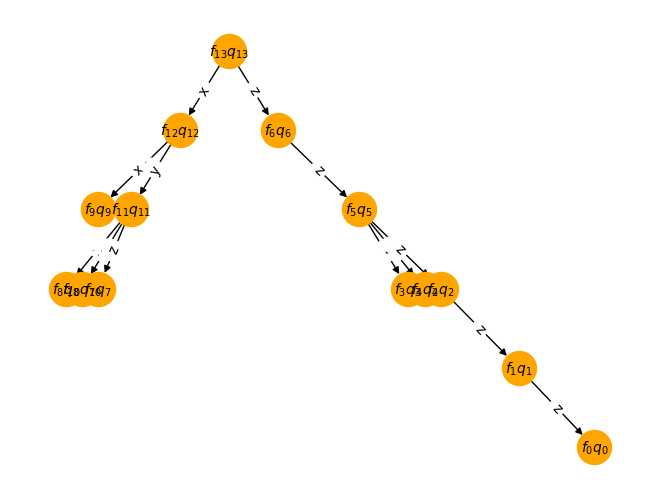

In [4]:
fast_hatt_tree = fast_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)
draw_tt(fast_hatt_tree, enumeration_scheme=fast_hatt_tree.default_enumeration_scheme())

# POC: Jordan-Wigner

For JW we enforce that we start with the node farthest from the root, then each subsequent node is attached as the Z-parent of the previous.

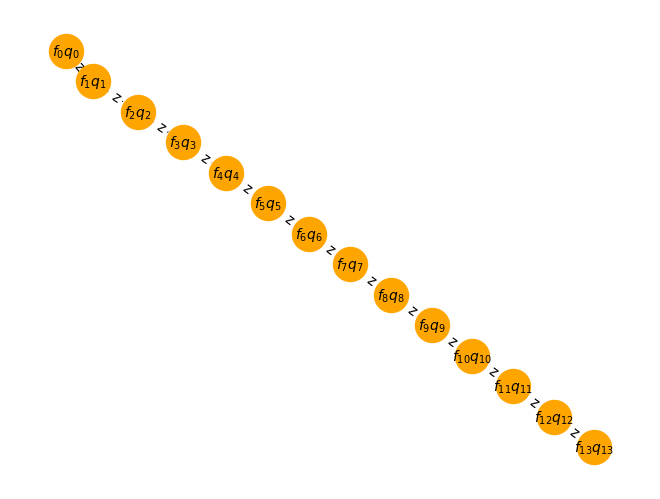

In [5]:
from ferrmion.encode import JordanWigner
from ferrmion.visualise import draw_tt
base_jw = JordanWigner(14)
draw_tt(base_jw, enumeration_scheme=base_jw.default_enumeration_scheme())

x
y
zx
zy
zzx
zzy
zzzx
zzzy
zzzzx
zzzzy
zzzzzx
zzzzzy
zzzzzzx
zzzzzzy
zzzzzzzx
zzzzzzzy
zzzzzzzzx
zzzzzzzzy
zzzzzzzzzx
zzzzzzzzzy
zzzzzzzzzzx
zzzzzzzzzzy
zzzzzzzzzzzx
zzzzzzzzzzzy
zzzzzzzzzzzzx
zzzzzzzzzzzzy
zzzzzzzzzzzzzx
zzzzzzzzzzzzzy
zzzzzzzzzzzzzz


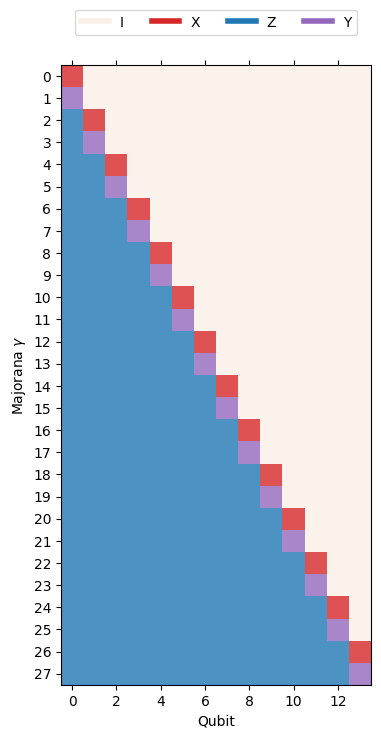

In [6]:
symplectic_matshow(JordanWigner(14)._build_symplectic_matrix()[1])

In [7]:
def jw_hatt(
    majorana_ham: dict[Iterable[int], float], n_modes: int, coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves+ i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        print(f"{len(unassigned)=}, {unassigned=}")
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        # reverse because best is usually at the end 
        # reversed_combinations = [c for c in combinations(unassigned, 2)]

        # Z-child of new node will always be the previous node.
        # We only need to use every second entry in unassigned
        # as we already order odd/even terms
        # we also know for jw that every new node will be
        # the z-ancestor all all other nodes.
        z_index = unassigned[0]
        for x_index in unassigned[1::2]:
            small_y = None
            small_x = None
            # Now that we are enforcing a topology
            # we actually need to set the combination
            comb = z_index, x_index

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # ) 
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # elif weight == min_weight:
            # #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
            #     min_weight = weight
            #     selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [ u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned
        
        if i +1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print(total_weight)
    return tree

In [8]:
from ferrmion.utils import fermionic_to_sparse_majorana
jw_hatt_tree = jw_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)

len(unassigned)=29, unassigned=[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=27, unassigned=[29, 27, 26, 25, 24, 23, 22, 21, 20, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=25, unassigned=[30, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=23, unassigned=[31, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=21, unassigned=[32, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=19, unassigned=[33, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=17, unassigned=[34, 23, 22, 21, 20, 15, 14, 13, 12, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=15, unassigned=[35, 23, 22, 21, 20, 15, 14, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=13, unassigned=[36, 23, 22, 21, 20, 15, 14, 7, 6, 3, 2, 1, 0]
len(unassigned)=11, unassigned=[37, 23

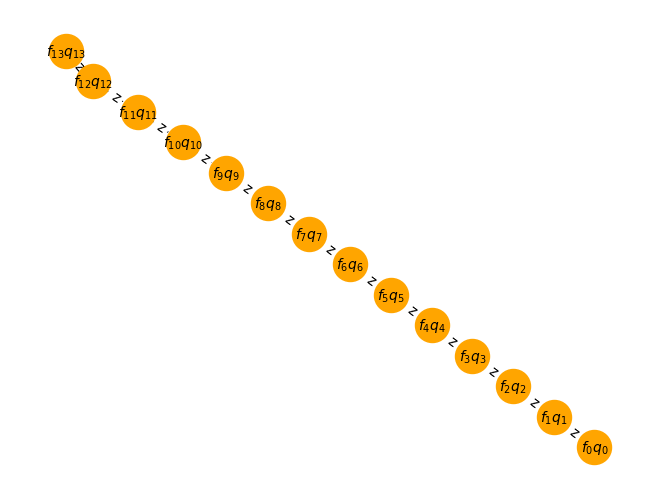

In [9]:
draw_tt(jw_hatt_tree, enumeration_scheme=jw_hatt_tree.default_enumeration_scheme())

x
y
zx
zy
zzx
zzy
zzzx
zzzy
zzzzx
zzzzy
zzzzzx
zzzzzy
zzzzzzx
zzzzzzy
zzzzzzzx
zzzzzzzy
zzzzzzzzx
zzzzzzzzy
zzzzzzzzzx
zzzzzzzzzy
zzzzzzzzzzx
zzzzzzzzzzy
zzzzzzzzzzzx
zzzzzzzzzzzy
zzzzzzzzzzzzx
zzzzzzzzzzzzy
zzzzzzzzzzzzzx
zzzzzzzzzzzzzy
zzzzzzzzzzzzzz


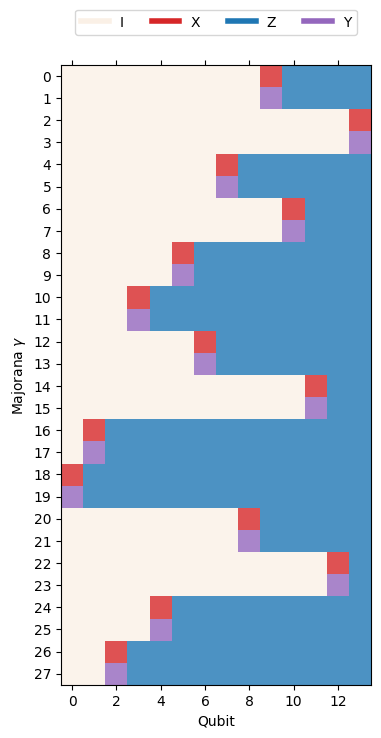

In [10]:
from ferrmion.visualise import symplectic_matshow
symplectic_matshow(jw_hatt_tree._build_symplectic_matrix()[1])

In [11]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [12]:
from ferrmion.hamiltonians import fill_template, molecular_hamiltonian_template
def fill_template_find_norms(template, ones, twos, permutation):
    permutation = np.array(permutation, dtype=np.uint)
    ham = fill_template(template, 0, ones, twos, permutation)
    
    return pauli_weights(ham)

# JW TOPPHATT 

In [13]:
from ferrmion.utils import fermionic_to_sparse_majorana
jw_hatt_tree = jw_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)
template = molecular_hamiltonian_template(*jw_hatt_tree._build_symplectic_matrix(), physicist_notation=True)
result = fill_template_find_norms(template, ones, twos, [*range(14)])
sdmeans_topphatt = {}
sdmeans_topphatt["unscaled"] = np.mean(result[0])
sdmeans_topphatt["scaled"] = np.mean(result[1])
sdmeans_topphatt["length"] = result[2]

len(unassigned)=29, unassigned=[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=27, unassigned=[29, 27, 26, 25, 24, 23, 22, 21, 20, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=25, unassigned=[30, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=23, unassigned=[31, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=21, unassigned=[32, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=19, unassigned=[33, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=17, unassigned=[34, 23, 22, 21, 20, 15, 14, 13, 12, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=15, unassigned=[35, 23, 22, 21, 20, 15, 14, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=13, unassigned=[36, 23, 22, 21, 20, 15, 14, 7, 6, 3, 2, 1, 0]
len(unassigned)=11, unassigned=[37, 23

# JW Naive

In [14]:
sdmeans_naive = {}
rng = np.random.RandomState(1017)

sym = JordanWigner(ones.shape[0])._build_symplectic_matrix()
template = molecular_hamiltonian_template(*sym, physicist_notation=True)

result = fill_template_find_norms(template, ones, twos, np.array([*range(ones.shape[0])], dtype=np.uint))
sdmeans_naive["unscaled"] = np.mean(result[0])
sdmeans_naive["scaled"] = np.mean(result[1])
sdmeans_naive["length"] = result[2]
sdmeans_naive

x
y
zx
zy
zzx
zzy
zzzx
zzzy
zzzzx
zzzzy
zzzzzx
zzzzzy
zzzzzzx
zzzzzzy
zzzzzzzx
zzzzzzzy
zzzzzzzzx
zzzzzzzzy
zzzzzzzzzx
zzzzzzzzzy
zzzzzzzzzzx
zzzzzzzzzzy
zzzzzzzzzzzx
zzzzzzzzzzzy
zzzzzzzzzzzzx
zzzzzzzzzzzzy
zzzzzzzzzzzzzx
zzzzzzzzzzzzzy
zzzzzzzzzzzzzz


{'unscaled': np.float64(7.057090239410681),
 'scaled': np.float64(0.17624542204398874),
 'length': 1086}

# JW Annealed

In [15]:
from ferrmion.core import anneal_enumerations    
import numpy as np
sdmeans_annealed = {}
annealed_best = anneal_enumerations(template, ones, twos, temperature=ones.shape[0], initial_guess=np.array([*range(ones.shape[0])],dtype=np.uint), coefficient_weighted=False)
result = fill_template_find_norms(template, ones, twos, annealed_best[1])
sdmeans_annealed["unscaled"] = np.mean(result[0])
sdmeans_annealed["scaled"] = np.mean(result[1])
sdmeans_annealed["length"] = result[2]
sdmeans_annealed

{'unscaled': np.float64(5.152854511970534),
 'scaled': np.float64(0.1280973136107841),
 'length': 1086}

# JW Random Permutations

In [16]:
limit = 100
sdmeans = {}
sdmeans = {"unscaled":[], "scaled":[], "length":[]}
i=0
while i < limit:
    perm = rng.permutation(ones.shape[0])
    result = fill_template_find_norms(template, ones, twos, perm)
    sdmeans["unscaled"].append(np.mean(result[0])) 
    sdmeans["scaled"].append(np.mean(result[1]))
    sdmeans["length"].append(result[2])
    i+=1
sdmeans.keys()

dict_keys(['unscaled', 'scaled', 'length'])

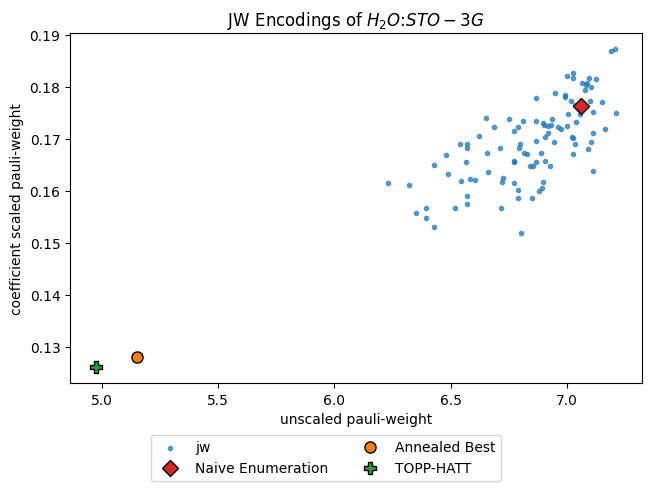

In [17]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "bonsai":"tab:purple", "huffman":"tab:brown", "hatt":"tab:pink"}
fig, ax = plt.subplots(layout="constrained")

for encoding in ["jw"]:
    color = color_set[encoding]
    # ax.scatter([],[], label=encoding, marker=".", color=color, alpha=0.7)
    ax.scatter(sdmeans["unscaled"], sdmeans["scaled"], label=encoding, marker=".", color=color_set[encoding], alpha=0.7)
    ax.plot(sdmeans_naive["unscaled"], sdmeans_naive["scaled"], marker="D", color="tab:red", mec="k", markersize=8)
    ax.plot(sdmeans_annealed["unscaled"], sdmeans_annealed["scaled"], marker="o", color="tab:orange", mec="k", markersize=8)
    ax.plot(sdmeans_topphatt["unscaled"], sdmeans_topphatt["scaled"], marker="P", color="tab:green", mec="k", markersize=8)


#Imports

# where some data has already been plotted to ax
handles, labels = plt.gca().get_legend_handles_labels()

# manually define a new patch 
naive_legend = mlines.Line2D([], [], label='Naive Enumeration', marker="D", linestyle="", color="tab:red", mec="k", markersize=8)
annealed_legend = mlines.Line2D([], [], label='Annealed Best', marker="o", linestyle="",color="tab:orange", mec="k", markersize=8)
topphatt_legend = mlines.Line2D([], [], label='TOPP-HATT', marker="P", linestyle="",color="tab:green", mec="k", markersize=8)

# handles is a list, so append manual patch
handles.extend([naive_legend, annealed_legend, topphatt_legend])

ax.set_xlabel("unscaled pauli-weight")
ax.set_ylabel("coefficient scaled pauli-weight")
ax.set_title("JW Encodings of $H_2 O$:$STO-3G$")
fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)

# TOPP-HATT

In [18]:
from ferrmion.encode import TernaryTree
def topp_hatt(
    majorana_ham: dict[Iterable[int], float],
    tree: TernaryTree,
    coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}
    n_modes = tree.n_modes
    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves+ i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        print(f"{len(unassigned)=}, {unassigned=}")
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        # reverse because best is usually at the end 
        # reversed_combinations = [c for c in combinations(unassigned, 2)]

        # Z-child of new node will always be the previous node.
        # We only need to use every second entry in unassigned
        # as we already order odd/even terms
        # we also know for jw that every new node will be
        # the z-ancestor all all other nodes.

        z_index = unassigned[0]
        for x_index in unassigned[1::2]:
            small_y = None
            small_x = None
            # Now that we are enforcing a topology
            # we actually need to set the combination
            comb = z_index, x_index

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # ) 
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # elif weight == min_weight:
            # #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
            #     min_weight = weight
            #     selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [ u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned
        
        if i +1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print(total_weight)
    return tree

# Plan

- Restrict the iterator in each loop to a product of allowed values for x,y,z


# Implementation steps
-[x] Product of allowed iterations, where allowed is simply unassigned

### Baseline FastHATT

In [19]:
def fast_hatt(
    majorana_ham: dict[Iterable[int], float],
    n_modes: int,
    coeff_weight: bool = False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.
        coeff_weight (bool): Multiply Pauli-weight by coefficient norm.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2 * n_modes + 1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves + i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves + n_modes)}

    total_weight = 0
    for i in range(n_modes + 1):
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        previous = [None, None, None]
        # reverse because best is usually at the end
        # reversed_combinations = [c for c in combinations(unassigned, 2)]
        if i == 0:
            comb_iterator = ([n_leaves - 1, i] for i in range(n_leaves - 1)[::-1])
        else:
            comb_iterator = permutations(unassigned, 2)

        for comb in comb_iterator:
            # print(f"{comb=}")
            small_y = None
            small_x = None
            # This way x index will be higher term - more often node.
            z_index, x_index = comb
            # x_index, z_index = comb

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                # print("small x is all z")
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            if comb == previous:
                continue
            previous = comb
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # weight = np.sum(
                #     [_qubit_term_weight(term, comb) for term in majorana_ham.keys()]
                # )
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # elif weight == min_weight:
                #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                # min_weight = weight
                # selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned

        if i + 1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print("Total Weight: ", total_weight)
    return tree

In [20]:
fast_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=14, coeff_weight=False)

selection=[18, 19, 28]
selection=[16, 17, 29]
selection=[26, 27, 30]
selection=[8, 9, 25]
selection=[10, 11, 24]
selection=[33, 32, 31]
selection=[12, 13, 34]
selection=[6, 7, 15]
selection=[4, 5, 14]
selection=[2, 3, 22]
selection=[38, 23, 36]
selection=[0, 1, 35]
selection=[20, 21, 40]
selection=[37, 39, 41]
Total Weight:  2551


## 'Allowed'

In [21]:
from ferrmion.encode import TernaryTree
from itertools import product
def topp_hatt(
    majorana_ham: dict[Iterable[int], float],
    tree: TernaryTree,
    coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}
    n_modes = tree.n_modes
    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves+ i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned_leaves = [*range(n_leaves)]
    unassigned_nodes = []
    unassigned_leaves.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        # print(f"Index {i},{unassigned_nodes=}, {unassigned_leaves=}")
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]

        # Z-child of new node will always be the previous node.
        # We only need to use every second entry in unassigned
        # as we already order odd/even terms
        # we also know for jw that every new node will be
        # the z-ancestor all all other nodes.
        allowed_x = unassigned_nodes + unassigned_leaves
        allowed_z = unassigned_nodes + unassigned_leaves
        for comb in product(allowed_x, allowed_z):
            # print(f"{comb=}")
            z_index, x_index = comb
            if z_index == x_index:
                continue

            small_y = None
            small_x = None

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # ) 
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # elif weight == min_weight:
            # #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                # min_weight = weight
                # selection = comb

        total_weight += min_weight
        print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned_leaves = [ u for u in unassigned_leaves if u not in selection]
        unassigned_nodes = [ u for u in unassigned_nodes if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        unassigned_nodes = [parent_index] + unassigned_nodes
        
        if i +1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)

    if len(unassigned_nodes) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned_leaves=}")

    last_node = nodes[unassigned_nodes[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print(total_weight)
    return tree

In [22]:
topp_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), tree=JordanWigner(14), coeff_weight=False)

selection=[18, 19, 28]
selection=[16, 17, 29]
selection=[26, 27, 30]
selection=[8, 9, 25]
selection=[10, 11, 24]
selection=[33, 32, 31]
selection=[12, 13, 34]
selection=[6, 7, 15]
selection=[4, 5, 14]
selection=[2, 3, 22]
selection=[38, 23, 36]
selection=[0, 1, 35]
selection=[20, 21, 40]
selection=[37, 39, 41]
2551


# Defining Restrictions

All Z-node
- Z-majorana must be 2n

Terminal nodes
- no restrictions, x,y,z majoranas can be any number.

Z-Parents
- Z-child must be retained

X-Parents
- X-child must be retained
- x-majorana of parent is z-leaf of X-child's z-decendant

Y-Parents
- Y-child must be retained
- y-majorana of parent is z-leaf of Y-child's z-decendant



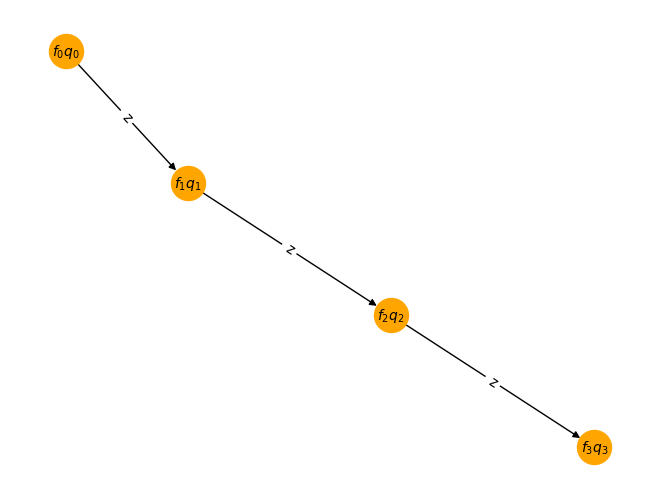

In [23]:
tree = JordanWigner(4)
draw_tt(tree, enumeration_scheme=tree.default_enumeration_scheme())

## Initialise the restrictions

We should be able to set all of these exactly, as we know the structure of the tree ahead of time.

In [24]:
from ferrmion.encode.ternary_tree_node import TTNode
def get_node(root_node: TTNode, child_string: str):
    node = root_node
    for char in child_string:
        node = getattr(node, char)
    return node

def add_all_z_restriction(tree,string_index_map, restrictions):
    child_strings = tree.root_node.child_strings
    all_z = sorted({child for child in child_strings if "x" not in child and "y" not in child}, key=len, reverse=True)[0]
    all_z_index = string_index_map[all_z]
    restrictions[all_z_index][2] = [2*tree.n_modes]
    return restrictions

def majorana_indices_of_node(node_index, n_leaves) -> int:
    x_majorana = 2*(node_index - n_leaves)
    y_majorana = x_majorana+1
    return x_majorana, y_majorana

def get_twinned_majorana_index(node: TTNode):
    index = node.leaf_majorana_indices["z"]
    if index is None:
        return None
    if index %2 == 0:
        return index + 1
    else:
        return index - 1


def add_retain_child_restrictions(tree:TernaryTree, string_index_map, restrictions):
    """Nodes that have a child."""
    child_strings = tree.root_node.child_strings
    for node in child_strings:
        if node == "":
            continue
        parent = node[:-1]
        parent_index = string_index_map[parent]
        node_index = string_index_map[node]
        match node[-1]:
            case "x":
                restrictions[parent_index][0] = [node_index]
            case "y":
                restrictions[parent_index][1] = [node_index]
            case "z":
                restrictions[parent_index][2] = [node_index]
    return restrictions

def add_xy_parent_restrictions(
        tree:TernaryTree, 
        string_index_map:dict[str,int], 
        node_objects_map:dict[int, TTNode],
        restrictions:dict[int, list[int|None]]
        ):
    """Nodes that have an X-parent or Y-parent."""
    child_strings = tree.root_node.child_strings
    parent_strings = {child[:-1] for child in child_strings}
    for parent in parent_strings:
        parent_index = string_index_map[parent]
        parent_node = node_objects_map[parent_index]
        match parent_node.x, parent_node.y:
            case None, None:
                continue
            case TTNode(), None:
                restrictions[parent_index][1] = lambda : None if (index:= parent_node.x.z_descendant.leaf_majorana_indices["z"]) is None else ([index +1] if index%2==0 else [index-1])  
            case None, TTNode():
                restrictions[parent_index][0] = lambda : None if (index:= parent_node.y.z_descendant.leaf_majorana_indices["z"]) is None else ([index -1] if index%2==0 else [index+1])  
            case TTNode(), TTNode():
                xz_descendant = parent_node.x.z_descendant
                yz_descendant = parent_node.y.z_descendant
                restrictions[string_index_map[xz_descendant.root_path]][2] = lambda: None if (index:= parent_node.x.z_descendant.leaf_majorana_indices["z"]) is None else ([index +1] if index%2==0 else [index-1])  
                restrictions[string_index_map[yz_descendant.root_path]][2] = lambda: None if (index:= parent_node.y.z_descendant.leaf_majorana_indices["z"]) is None else ([index -1] if index%2==0 else [index+1])  
            case _:
                raise ValueError("Node root strings should end in one of: x,y,z.")
    return restrictions

def get_string_index_map(tree):
    n_leaves = 2*tree.n_modes+1
    enumeration_scheme = tree.default_enumeration_scheme()
    child_strings = tree.root_node.child_strings
    return {child: n_leaves+enumeration_scheme[child][1] for child in child_strings}

def get_node_objects_map(tree, string_index_map):
    return {string_index_map[child]: get_node(tree.root_node, child) for child in tree.root_node.child_strings}

def initialise_restrictions(tree:TernaryTree):
    string_index_map = get_string_index_map(tree)
    node_objects_map = get_node_objects_map(tree, string_index_map)
    # each node has restrictions in tuple (restrictions on x, restrictions on y, restrictions on z)
    restrictions = {i: [None, None, None] for i in string_index_map.values()}
    restrictions = add_all_z_restriction(tree,string_index_map, restrictions)
    restrictions = add_retain_child_restrictions(tree, string_index_map, restrictions)
    # restrictions = add_xy_parent_restrictions(tree, string_index_map, node_objects_map, restrictions)
    return restrictions

In [27]:
from ferrmion.encode import BK
def initialise_node_dependencies(tree:TernaryTree):
    string_index_map = get_string_index_map(tree)
    node_objects_map = get_node_objects_map(tree, string_index_map)
    child_strings = tree.root_node.child_strings
    dependencies = {string_index_map[child]:[] for child in child_strings}

    for child in child_strings:
        for char in ["x","y","z"]:
            if child+char in child_strings:
                dependencies[string_index_map[child]].append(string_index_map[child+char])
    return dependencies

initialise_node_dependencies(BK(4))

{9: [10], 10: [11, 12], 11: [], 12: []}

In [28]:
jwr = initialise_restrictions(JordanWigner(4))
jwr

{9: [None, None, [10]],
 10: [None, None, [11]],
 11: [None, None, [12]],
 12: [None, None, [8]]}

# Find the restrictions for a single node

In [29]:
# def add_all_z_restriction(tree,node_string, string_index_map, restrictions:list[int])->list[int]:
#     if "x" not in node_string:
#         return restrictions
#     if "y" not in node_string:
#         return restrictions
#     if node_string+"z" in tree.root_node.child_strings:
#         return restrictions

#     restrictions[2] = [2*tree.n_modes]
#     return restrictions

# def majorana_indices_of_node(node_index, n_leaves) -> int:
#     x_majorana = 2*(node_index - n_leaves)
#     y_majorana = x_majorana+1
#     return x_majorana, y_majorana

# def get_twinned_majorana_index(node: TTNode):
#     index = node.leaf_majorana_indices["z"]
#     if index is None:
#         return None
#     if index %2 == 0:
#         return index + 1
#     else:
#         return index - 1

# def add_retain_child_restrictions(tree:TernaryTree, node_string:str, string_index_map:dict[str,int], restrictions:list[int])->list[int]:
#     """Add restriction that the node retains its children in the correct location."""
#     child_strings = tree.root_node.child_stringss
#     node_index = string_index_map[node_string]
#     if node_string+"x" in child_strings:
#         restrictions[0] = [string_index_map[node_string+"x"]]
#     if node_string+"y" in child_strings:
#         restrictions[1] = [string_index_map[node_string+"y"]]
#     if node_string+"z" in child_strings:
#         restrictions[2] = [string_index_map[node_string+"z"]]
#     return restrictions

def add_z_descendant_restrictions(tree:TernaryTree, node_string:str, string_index_map:dict[str,int], node_objects_map:dict[int, TTNode], restrictions:list[int|None]):
    if node_string+"z" in tree.root_node.child_strings:
        return restrictions
    
    node_index = string_index_map[node_string]
    node:TTNode = node_objects_map[node_index]
    
    z_ancestor = node.z_ancestor
    if z_ancestor.root_path == "":
        return restrictions
    elif z_ancestor.root_path[-1] 
    print(f"{z_ancestor=}")
    
    match z_ancestor.root_path[-1]:
        case "z":
            raise ValueError("Z-ancestor root path should never end in Z.")
        case "x":
            origin_node = z_ancestor.parent
            if isinstance(origin_node.y, TTNode):
                restrictions[2] = origin_node.y.z_ancestor.leaf_majorana_indices["z"]
            elif origin_node.y is None:
                restrictions[2] = origin_node.branch_majorana_map["y"]
            # If it is non-none, (an integer), we need the pair of the y leaf
            if restrictions[2] is not None:
                restrictions[2] -= 1.
        case "y":
            origin_node = z_ancestor.parent
            if isinstance(origin_node.x, TTNode):
                restrictions[2] = origin_node.x.z_ancestor.leaf_majorana_indices["z"]
            elif origin_node.x is None:
                restrictions[2] = origin_node.branch_majorana_map["y"]
            # If it is non-none, (an integer), we need the pair of the y leaf
            if restrictions[2] is not None:
                restrictions[2] += 1.
        case _:
            raise ValueError(f"Z ancestor root path {z_ancestor.root_path} should end in one of: x,y,z")
    return restrictions


# def get_single_node_restrictions(node_index:int, tree:TernaryTree):
#     string_index_map = get_string_index_map(tree)
#     index_string_map = {v:k for k,v in string_index_map.items()}
#     node_string = index_string_map[node_index]

#     node_objects_map = get_node_objects_map(tree, string_index_map)
#     # each node has restrictions in tuple (restrictions on x, restrictions on y, restrictions on z)
#     restrictions = [None, None, None]
#     restrictions = add_all_z_restriction(tree, node_string, string_index_map, restrictions)
#     restrictions = add_retain_child_restrictions(tree, string_index_map, restrictions)
#     restrictions = add_xy_parent_restrictions(tree, string_index_map, node_objects_map, restrictions)
#     return restrictions

SyntaxError: expected ':' (141782352.py, line 48)

In [30]:
from ferrmion.encode import TernaryTree
from types import LambdaType
from itertools import product
from typing import Callable

def build_valid_combination(comb: tuple[int,int], 
                      descendant_map:dict, 
                      ancestor_map:dict, 
                      n_modes:int, 
                      selection:list[int,int,int], 
                      ) -> None|list[int,int,int]:
    # print(f"{comb=}")
    z_index, x_index = comb
    if z_index == x_index:
        return None

    small_y = None
    small_x = None

    small_x = descendant_map[x_index]

    # discard this combination
    if small_x == 2 * n_modes:
        return None

    if small_x % 2 == 0:
        small_y = small_x + 1
    else:
        small_y = small_x - 1
    # We can't use this index for y a
    # it has been used in the combination already
    # so we'd be replacing our x or z!
    if small_y in comb:
        return None

    y_index = ancestor_map[small_y]

    if y_index in comb:
        return None

    if small_x % 2 == 0:
        comb = [x_index, y_index, z_index]
    else:
        comb = [y_index, x_index, z_index]

    # W3 can end uop with the same combination in two different ways
    if comb == selection:
        return None
    return comb

def unpack_single_restriction(restriction: None|list[int]|Callable, unassigned_leaves:set):
    if restriction is None:
        restriction = unassigned_leaves
    elif isinstance(restriction, LambdaType):
        restriction = restriction()
    return restriction

def topp_hatt(
    majorana_ham: dict[Iterable[int], float],
    tree: TernaryTree,
    coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}
    n_modes = tree.n_modes
    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves-1)}
    node_dependencies = initialise_node_dependencies(tree)
    print(node_dependencies)

    string_index_map = get_string_index_map(tree)
    index_string_map = {v:k for k,v in string_index_map.items()}
    node_objects_map = get_node_objects_map(tree, string_index_map)

    nodes.update(get_node_objects_map(tree, string_index_map))
    
    active_nodes:set[int] = {node for node, deps in node_dependencies.items() if deps == []}
    completed_nodes = set()
    print(f"{active_nodes=}")
    restrictions = initialise_restrictions(tree)
    print(f"{restrictions=}")
    # Start with all the leaves unassigned
    unassigned_leaves = [*range(n_leaves)]
    unassigned_leaves.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        print(f"\n Iteration {i}")
        print(f"{restrictions=}")
        print(f"{active_nodes=}")


        # Update the restrictions with the new information about the tree.
        # Any nodes that are required to be in a certain position 
        # have to be removed from unassigned!
        to_remove = []
        for restriction in restrictions.values():
            for term in restriction:
                if isinstance(term, list) and len(term)==1:
                    to_remove.append(term[0])

        unassigned_leaves = [l for l in unassigned_leaves if l not in to_remove]
        print(f"{unassigned_leaves=}")

        print(f"Index {i},{active_nodes=}, {unassigned_leaves=}")
        print(f"{restrictions=}")
        min_weight = np.inf
        min_parent = None
        selection = [None, None, None]
        
        # NOTE
        # Another opion would be to check all allowed
        # combinations just once and then to look 
        # for the parent that is eligable for the minimum combination.
        for parent_index in active_nodes:
            print(f"\nPossible Parent {parent_index}")

            parent:TTNode = nodes[parent_index]

            # Z-child of new node will always be the previous node.
            # We only need to use every second entry in unassigned
            # as we already order odd/even terms
            # we also know for jw that every new node will be
            # the z-ancestor all all other nodes.

            parent_restrictions = restrictions[parent_index]
            print(f"{parent_restrictions=}")
            

            allowed_x = unpack_single_restriction(parent_restrictions[0], unassigned_leaves)
            allowed_y = unpack_single_restriction(parent_restrictions[1], unassigned_leaves)
            allowed_z = unpack_single_restriction(parent_restrictions[2], unassigned_leaves)

            match parent_restrictions[0], parent_restrictions[1]:
                case None, None:
                    allowed_product = product(allowed_z, allowed_x)
                case list(), None:
                    allowed_product = product(allowed_z, allowed_x)
                case None, list():
                    allowed_product = product(allowed_z, allowed_y)
                case list(), list():
                    allowed_product = product(allowed_x, allowed_y, allowed_z)

            print(f"{allowed_x=}, {allowed_y=}, {allowed_z=}")
            # If x and y are both none, just do all x and create a pair
            # if x is none and y is set, just use y
            # if x is set and y is none, just use x


            for comb in allowed_product:
                match len(comb):
                    case 2:
                        comb = build_valid_combination(comb, descendant_map, ancestor_map, n_modes, selection)
                        if comb is None:
                            continue
                    case 3:
                        # We can use the combination provided
                        pass
                    case _:
                        raise ValueError("Length of combination should be 2 or 3.")
                print(comb)

                weight = 0
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break

                if weight < min_weight:
                    # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                    min_weight = weight
                    selection = comb
                    min_parent = parent_index
                # elif weight == min_weight:
                # #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                    # min_weight = weight
                    # selection = comb 

        total_weight += min_weight

        print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned_leaves = [ u for u in unassigned_leaves if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # the tree structure already exists
                # we just want to add leaf_majorana_indices
                pass
            else:
                parent.leaf_majorana_indices[char] = child_index

        # TODO this is only correct if the parent only has one child.
        
        if i +1 == n_modes:
            break

        
        completed_nodes.add(min_parent)
        node_dependencies.pop(min_parent)
        active_nodes.remove(min_parent)
        for node,deps in node_dependencies.items():
            if completed_nodes.issuperset(deps):
                active_nodes.add(node)
        

        z_index = selection[2]

        # Update the restrictions on the parent node to be its selection.
        restrictions[min_parent] = selection
        # Use these to update restrictions on other nodes.

        parent_node = node_objects_map[min_parent]
        print(f"{parent.root_path=}")
        print(f"{parent_node=}")
        print(f"{parent_node.parent=}")


        # The node may be its own z-ancestor
        restrictor = parent_node.z_ancestor
        print(restrictor)

        if restrictor.root_path is "":
            pass
        elif restrictor.root_path[-1]=="x":
            if isinstance(restrictor.parent.y,TTNode):
                restricted = restrictor.parent.y.z_descendant
                restrictions[string_index_map[restricted.root_path]][2] = [restrictor.z_descendant.leaf_majorana_indices["z"] +1]
            elif restrictor.parent.y is None:
                restricted = restrictor.parent
                restrictions[string_index_map[restricted.root_path]][1] = [restrictor.z_descendant.leaf_majorana_indices["z"] +1]

                
        elif parent_node.root_path[-1]=="y":
            if isinstance(parent_node.parent.x,TTNode):
                restricted = parent_node.parent.x.z_descendant
                restrictions[string_index_map[restricted.root_path]][2] = [restrictor.z_descendant.leaf_majorana_indices["z"] -1]
            elif parent_node.parent.x is None:
                restricted = parent_node.parent
                restrictions[string_index_map[restricted.root_path]][1] = [restrictor.z_descendant.leaf_majorana_indices["z"] -1]


        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)

    if len(active_nodes) != 1:
        print(active_nodes)
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned_leaves=}")

    last_node = nodes[active_nodes.pop()]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree.pauli_weight = total_weight
    print(total_weight)
    return tree

<>:245: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:245: SyntaxWarning: "is" with a literal. Did you mean "=="?
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_25726/3280005794.py:245: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if restrictor.root_path is "":


In [31]:
topp_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), tree=JordanWigner(14), coeff_weight=False)        

{29: [30], 30: [31], 31: [32], 32: [33], 33: [34], 34: [35], 35: [36], 36: [37], 37: [38], 38: [39], 39: [40], 40: [41], 41: [42], 42: []}
active_nodes={42}
restrictions={29: [None, None, [30]], 30: [None, None, [31]], 31: [None, None, [32]], 32: [None, None, [33]], 33: [None, None, [34]], 34: [None, None, [35]], 35: [None, None, [36]], 36: [None, None, [37]], 37: [None, None, [38]], 38: [None, None, [39]], 39: [None, None, [40]], 40: [None, None, [41]], 41: [None, None, [42]], 42: [None, None, [28]]}

 Iteration 0
restrictions={29: [None, None, [30]], 30: [None, None, [31]], 31: [None, None, [32]], 32: [None, None, [33]], 33: [None, None, [34]], 34: [None, None, [35]], 35: [None, None, [36]], 36: [None, None, [37]], 37: [None, None, [38]], 38: [None, None, [39]], 39: [None, None, [40]], 40: [None, None, [41]], 41: [None, None, [42]], 42: [None, None, [28]]}
active_nodes={42}
unassigned_leaves=[27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3,

In [32]:
from ferrmion.encode import ParityEncoding

In [33]:
bkhatt = topp_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), tree=ParityEncoding(14), coeff_weight=False)        

{29: [30], 30: [31], 31: [32], 32: [33], 33: [34], 34: [35], 35: [36], 36: [37], 37: [38], 38: [39], 39: [40], 40: [41], 41: [42], 42: []}
active_nodes={42}
restrictions={29: [[30], None, [28]], 30: [[31], None, None], 31: [[32], None, None], 32: [[33], None, None], 33: [[34], None, None], 34: [[35], None, None], 35: [[36], None, None], 36: [[37], None, None], 37: [[38], None, None], 38: [[39], None, None], 39: [[40], None, None], 40: [[41], None, None], 41: [[42], None, None], 42: [None, None, None]}

 Iteration 0
restrictions={29: [[30], None, [28]], 30: [[31], None, None], 31: [[32], None, None], 32: [[33], None, None], 33: [[34], None, None], 34: [[35], None, None], 35: [[36], None, None], 36: [[37], None, None], 37: [[38], None, None], 38: [[39], None, None], 39: [[40], None, None], 40: [[41], None, None], 41: [[42], None, None], 42: [None, None, None]}
active_nodes={42}
unassigned_leaves=[27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3,

In [34]:
BK(14).as_dict()

{'x': {'x': {'x': {'x': {'x': None, 'y': None, 'z': None},
    'y': None,
    'z': {'x': None, 'y': None, 'z': None}},
   'y': None,
   'z': {'x': {'x': None, 'y': None, 'z': None},
    'y': None,
    'z': {'x': None, 'y': None, 'z': None}}},
  'y': None,
  'z': {'x': {'x': {'x': None, 'y': None, 'z': None},
    'y': None,
    'z': {'x': None, 'y': None, 'z': None}},
   'y': None,
   'z': {'x': None, 'y': None, 'z': None}}},
 'y': None,
 'z': None}

In [36]:
bkhatt.root_node.branch_majorana_map

{'y': 14,
 'z': 28,
 'xy': 16,
 'xz': 13,
 'xxy': 24,
 'xxz': 15,
 'xxxy': 2,
 'xxxz': 23,
 'xxxxy': 6,
 'xxxxz': 1,
 'xxxxxy': 11,
 'xxxxxz': 5,
 'xxxxxxy': 28,
 'xxxxxxz': 10,
 'xxxxxxxy': 25,
 'xxxxxxxz': 27,
 'xxxxxxxxy': 9,
 'xxxxxxxxz': 24,
 'xxxxxxxxxy': 12,
 'xxxxxxxxxz': 8,
 'xxxxxxxxxxy': 26,
 'xxxxxxxxxxz': 11,
 'xxxxxxxxxxxy': 19,
 'xxxxxxxxxxxz': 25,
 'xxxxxxxxxxxxy': 20,
 'xxxxxxxxxxxxz': 18,
 'xxxxxxxxxxxxxx': 16,
 'xxxxxxxxxxxxxy': 17,
 'xxxxxxxxxxxxxz': 19}

In [35]:
bkhatt._build_symplectic_matrix()

y
z
xy
xz
xxy
xxz
xxxy
xxxz
xxxxy
xxxxz
xxxxxy
xxxxxz
xxxxxxy


IndexError: index 28 is out of bounds for axis 0 with size 28

In [37]:
from numpy.typing import NDArray
import logging
from ferrmion.encode.ternary_tree import string_pairing_algorithm
logger = logging.getLogger(__name__)

def _build_symplectic_matrix(
    self,
) -> tuple[NDArray[np.uint8], NDArray[bool]]:
    """Build the symplectic matrix for the tree.

    Returns:
        NDArray[np.uint8]: Powers of i for each row of the symplectic matrix.
        NDArray[np.uint8]: Symplectic matrix.

    Example:
        >>> from ferrmion.encode.ternary_tree import TernaryTree
        >>> tree = TernaryTree(3)
        >>> tree.add_node('x')
        >>> tree.enumeration_scheme = tree.default_enumeration_scheme()
        >>> tree._build_symplectic_matrix()
        (array([0, 1, 0, 1, 0, 1], dtype=uint8),
        array([[ True, False, False, False,  True,  True],
                [ True, False, False,  True, False, False],
                [ True,  True, False, False, False, False],
                [ True,  True, False, False,  True, False],
                [ True, False,  True, False,  True, False],
                [ True, False,  True, False,  True,  True]]))
    """
    logger.debug("Building symplectic matrix for TernaryTree.")
    if self.enumeration_scheme is None or self.enumeration_scheme == {}:
        logger.warning("No enumeration scheme provided, using default.")
        self.enumeration_scheme = self.default_enumeration_scheme()
    logger.debug(f"{self.enumeration_scheme=}")

    branch_majorana_map = self.root_node.branch_majorana_map
    logger.debug(f"{branch_majorana_map=}")
    if None in [
        *branch_majorana_map.values()
    ] or self.root_node.branch_strings.symmetric_difference(
        branch_majorana_map.keys()
    ):
        logger.info("Branches do not have majorana indices assigned for all modes.")
        logger.info(
            "Using string-pairing algorithm to assign majorana indices to branches."
        )
        branch_majorana_map = string_pairing_algorithm(self)

    pauli_string_map = self.branch_pauli_map

    symplectic = np.zeros((2 * self.n_qubits, 2 * self.n_qubits), dtype=bool)
    ipowers = np.zeros((2 * self.n_qubits), dtype=np.uint8)
    for operator, majorana_index in branch_majorana_map.items():
        print(operator, majorana_index)
        if "x" not in operator and "y" not in operator:
            continue

        operator = pauli_string_map[operator]
        operator = np.array(list(operator), dtype=str)
        # If the string is X or Y then assign 1
        symplectic_term, term_ipower = self._pauli_to_symplectic(operator, 0)

        ipowers[majorana_index] = term_ipower
        symplectic[majorana_index] = symplectic_term
    return ipowers, symplectic

In [38]:
_build_symplectic_matrix(bkhatt)

y 14
z 28
xy 16
xz 13
xxy 24
xxz 15
xxxy 2
xxxz 23
xxxxy 6
xxxxz 1
xxxxxy 11
xxxxxz 5
xxxxxxy 28


IndexError: index 28 is out of bounds for axis 0 with size 28